## 1. Data Understanding

In this section, we load the Netflix dataset and examine its structure,
size, columns, data types, and missing values.

The original dataset contains information about Netflix movies and TV shows.

In [1]:
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Size

The dataset contains 8,807 titles and 12 columns.

In [2]:
df.shape

(8807, 12)

### Dataset Columns

The dataset contains 12 columns that provide information about each Netflix title, including its title, content type, director, cast, country, release year, rating, duration, categories, and description.

In [76]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

### Data Types and Missing Values

The `df.info()` function is used to examine the data types of each column and identify columns that contain missing values.

This helps us understand the quality and structure of the dataset before performing data cleaning.

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### Missing Value Analysis

The dataset contains missing values in several columns.

The `director` column has the highest number of missing values, followed by `country` and `cast`. A small number of values are also missing from `date_added`, `rating`, and `duration`.

These missing values will be handled during the data cleaning process.

In [78]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [81]:
df[df["duration"].isnull()][["title", "type", "duration"]]

,title,type,duration
5541,Louis C.K. 2017,Movie,NaN
5794,Louis C.K.: Hilarious,Movie,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,NaN


In [82]:
df[df["rating"].isnull()][["title", "type", "rating"]]

,title,type,rating
5989,13TH: A Conversation with Oprah Winfrey & Ava ...,Movie,NaN
6827,Gargantia on the Verdurous Planet,TV Show,NaN
7312,Little Lunch,TV Show,NaN
7537,My Honor Was Loyalty,Movie,NaN


In [83]:
df[df["date_added"].isnull()][["title", "type", "date_added"]]

,title,type,date_added
6066,A Young Doctor's Notebook and Other Stories,TV Show,NaN
6174,Anthony Bourdain: Parts Unknown,TV Show,NaN
6795,Frasier,TV Show,NaN
6806,Friends,TV Show,NaN
6901,Gunslinger Girl,TV Show,NaN
7196,Kikoriki,TV Show,NaN
7254,La Familia P. Luche,TV Show,NaN
7406,Maron,TV Show,NaN
7847,Red vs. Blue,TV Show,NaN
8182,The Adventures of Figaro Pho,TV Show,NaN


## 2. Data Cleaning

Before performing exploratory data analysis, the dataset was cleaned to
handle missing values and incorrect data entries.

The cleaning process included:

- Creating a separate copy of the original dataset
- Handling missing values in text columns
- Converting the `date_added` column into a date format
- Correcting incorrect values found in the `rating` column
- Keeping genuinely unavailable information as `Unknown` instead of
  making assumptions

In [84]:
df_clean = df.copy()

### Handling Missing Values

Missing values in the `director`, `cast`, `country`, `rating`, and
`duration` columns were replaced with `"Unknown"`.

This approach preserves the records while clearly indicating that
the information was not available in the original dataset.

In [85]:
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["rating"] = df_clean["rating"].fillna("Unknown")
df_clean["duration"] = df_clean["duration"].fillna("Unknown")

In [86]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [87]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [88]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    format="mixed",
    errors="coerce"
)

In [89]:
df_clean["date_added"].isnull().sum()

np.int64(98)

In [90]:
df_clean = df.copy()

In [91]:
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["rating"] = df_clean["rating"].fillna("Unknown")
df_clean["duration"] = df_clean["duration"].fillna("Unknown")

In [92]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

In [93]:
df_clean["date_added"].isnull().sum()

np.int64(98)

In [94]:
df["date_added"].dropna().head(20)

0     September 25, 2021
1     September 24, 2021
2     September 24, 2021
3     September 24, 2021
4     September 24, 2021
5     September 24, 2021
6     September 24, 2021
7     September 24, 2021
8     September 24, 2021
9     September 24, 2021
10    September 24, 2021
11    September 23, 2021
12    September 23, 2021
13    September 22, 2021
14    September 22, 2021
15    September 22, 2021
16    September 22, 2021
17    September 22, 2021
18    September 22, 2021
19    September 22, 2021
Name: date_added, dtype: str

In [95]:
df["date_added"].dtype

<StringDtype(storage='python', na_value=nan)>

In [96]:
df["date_added"].isnull().sum()

np.int64(10)

In [97]:
df_clean = df.copy()

In [98]:
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["rating"] = df_clean["rating"].fillna("Unknown")
df_clean["duration"] = df_clean["duration"].fillna("Unknown")

### Converting Date Values

The `date_added` column was converted from text format to a proper
datetime format using Pandas.

The `format="mixed"` option allows different date formats to be
processed correctly, while `errors="coerce"` handles invalid values
without stopping the analysis.

The 10 genuinely missing dates were kept as missing values rather
than assigning incorrect dates.

In [99]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    format="mixed",
    errors="coerce"
)

In [100]:
df_clean["date_added"].isnull().sum()

np.int64(10)

In [101]:
df_clean.shape

(8807, 12)

In [102]:
df_clean.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [103]:
df_clean.to_csv("../data/netflix_cleaned.csv", index=False)

## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to identify patterns,
trends, and relationships within the Netflix dataset.

The analysis focuses on content type, release years, countries,
categories, ratings, movie durations, and TV show seasons.

#### Visualization

The following bar chart shows the distribution of Movies and TV Shows
in the Netflix dataset.

### 3.1 Movies vs TV Shows

The first analysis compares the number of Movies and TV Shows available
in the dataset.

This helps us understand the overall composition of Netflix content.

In [104]:
df_clean["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [105]:
type_percentage = df_clean["type"].value_counts(normalize=True) * 100

type_percentage

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

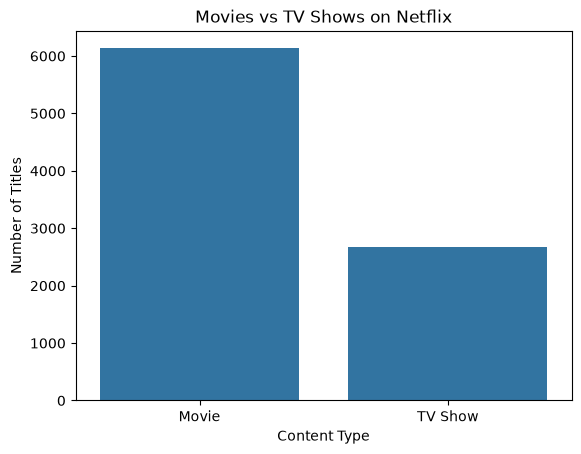

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_clean, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

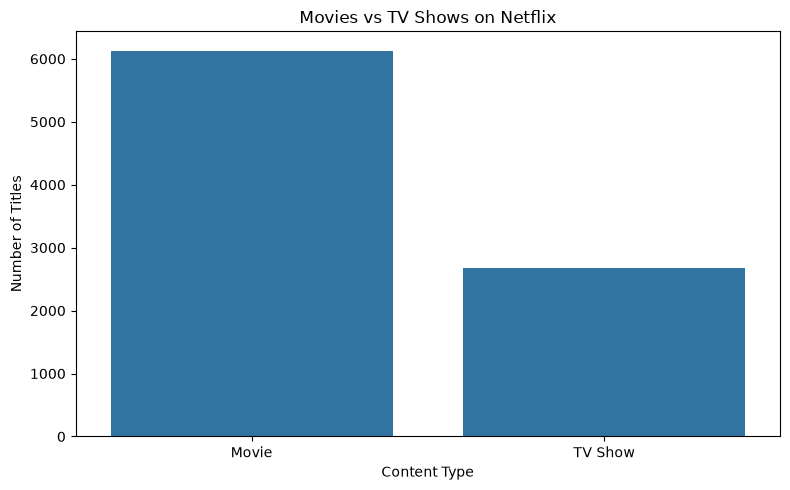

In [107]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("../visualizations/movies_vs_tv_shows.png", dpi=300)

plt.show()

#### Key Insight

Movies make up approximately 69.6% of the titles in the dataset,
while TV Shows account for approximately 30.4%.

This shows that Movies are the dominant content type in this Netflix
dataset.

### 3.2 Release Year Analysis

This analysis examines the number of Netflix titles released in each
year.

Studying release years helps us understand how the distribution of
Netflix content has changed over time.

In [108]:
release_year_counts = df_clean["release_year"].value_counts().sort_index()

release_year_counts

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

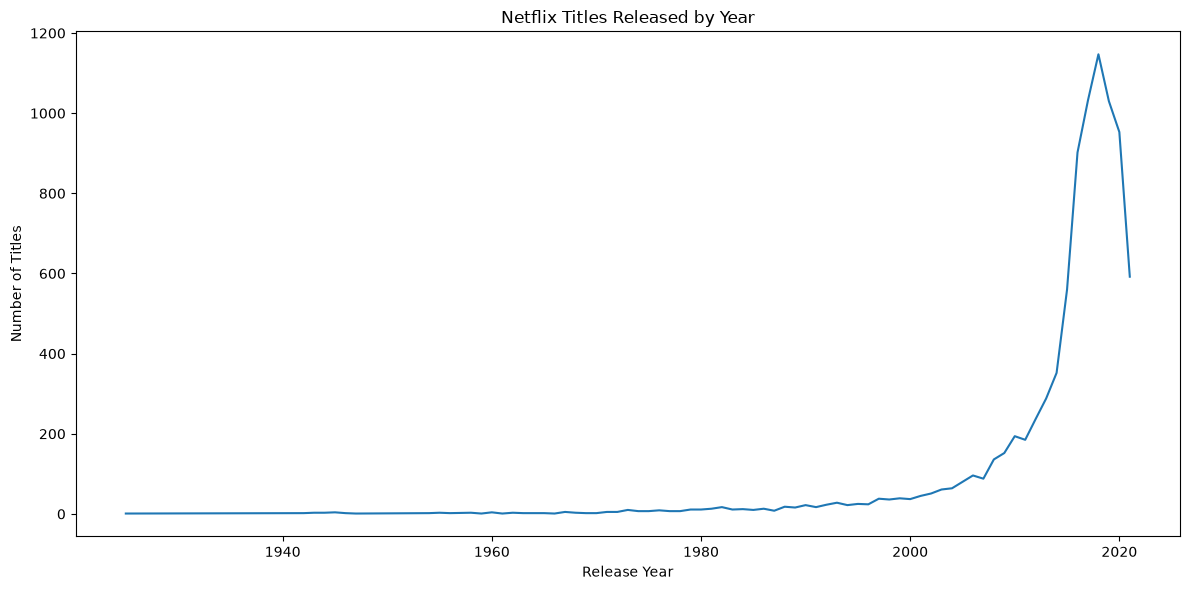

In [109]:
plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title("Netflix Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

#### Visualization

The line chart below shows the number of Netflix titles released each
year. The analysis focuses on recent years to make the trend easier to
interpret.

#### Key Insight

The number of titles in the dataset increases substantially in the
more recent release years, with the highest number of titles appearing
around 2018.

This suggests that the dataset contains a large amount of relatively
recent Netflix content.

Note: `release_year` represents the original release year of the title,
not the year it was added to Netflix.

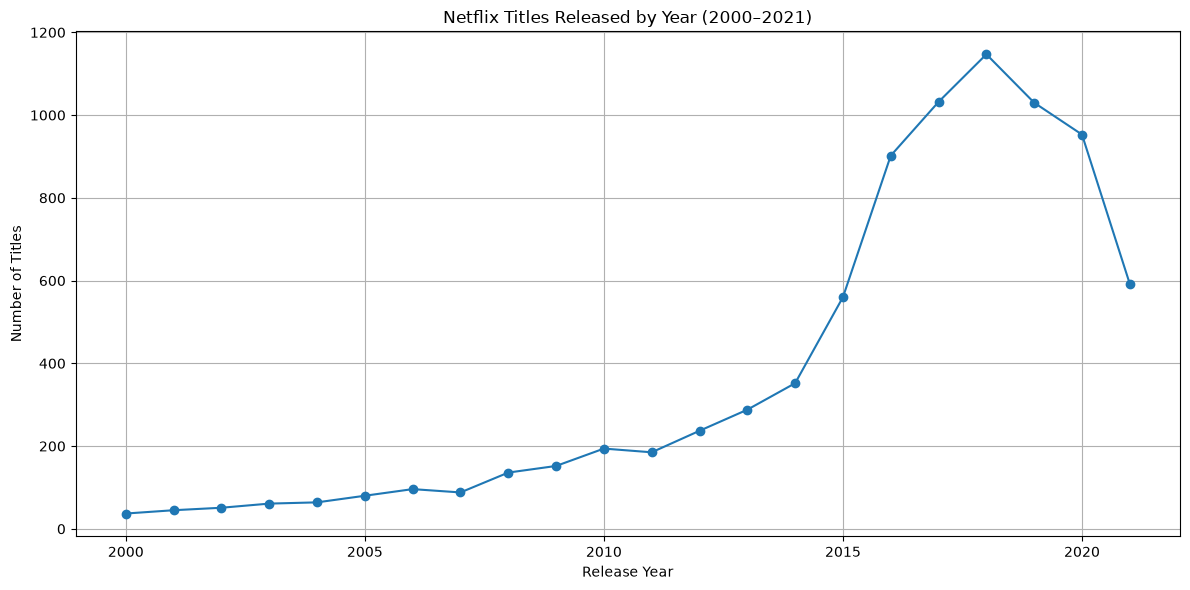

In [110]:
recent_years = release_year_counts[release_year_counts.index >= 2000]

plt.figure(figsize=(12, 6))

plt.plot(
    recent_years.index,
    recent_years.values,
    marker="o"
)

plt.title("Netflix Titles Released by Year (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.tight_layout()
plt.show()

### 3.3 Movies vs TV Shows Over Time

This analysis compares the number of Movies and TV Shows released
across different years.

It helps us understand whether the growth in Netflix titles over time
is mainly driven by Movies, TV Shows, or both.

In [111]:
type_by_year = (
    df_clean
    .groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

type_by_year

type,Movie,TV Show
release_year,,
1925,0,1
1942,2,0
1943,3,0
1944,3,0
1945,3,1
...,...,...
2017,767,265
2018,767,380
2019,633,397


#### Visualization

The line chart compares the number of Movies and TV Shows released
from 2000 to 2021.

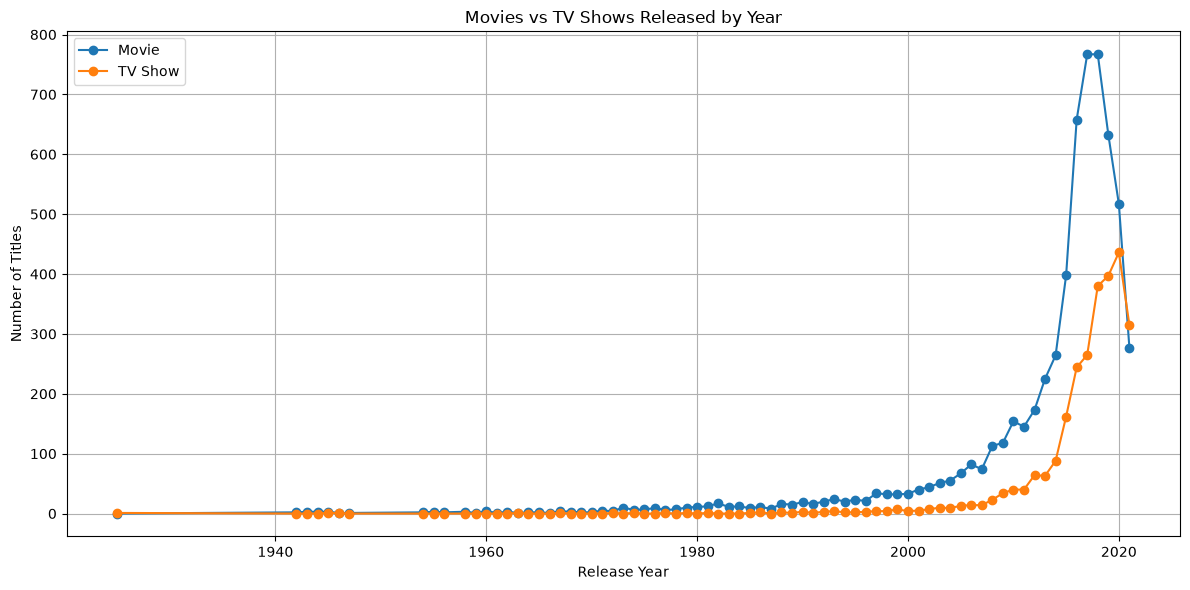

In [112]:
plt.figure(figsize=(12, 6))

plt.plot(
    type_by_year.index,
    type_by_year["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    type_by_year.index,
    type_by_year["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Movies vs TV Shows Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Key Insight

Movies consistently outnumber TV Shows across most of the years
analyzed.

Both Movies and TV Shows show a noticeable increase in the number of
titles released during the more recent years, particularly after 2015.

This indicates strong growth in both content types, with Movies
remaining the larger category.

In [113]:
recent_type_by_year = type_by_year[
    type_by_year.index >= 2000
]

recent_type_by_year

type,Movie,TV Show
release_year,,
2000,33,4
2001,40,5
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23


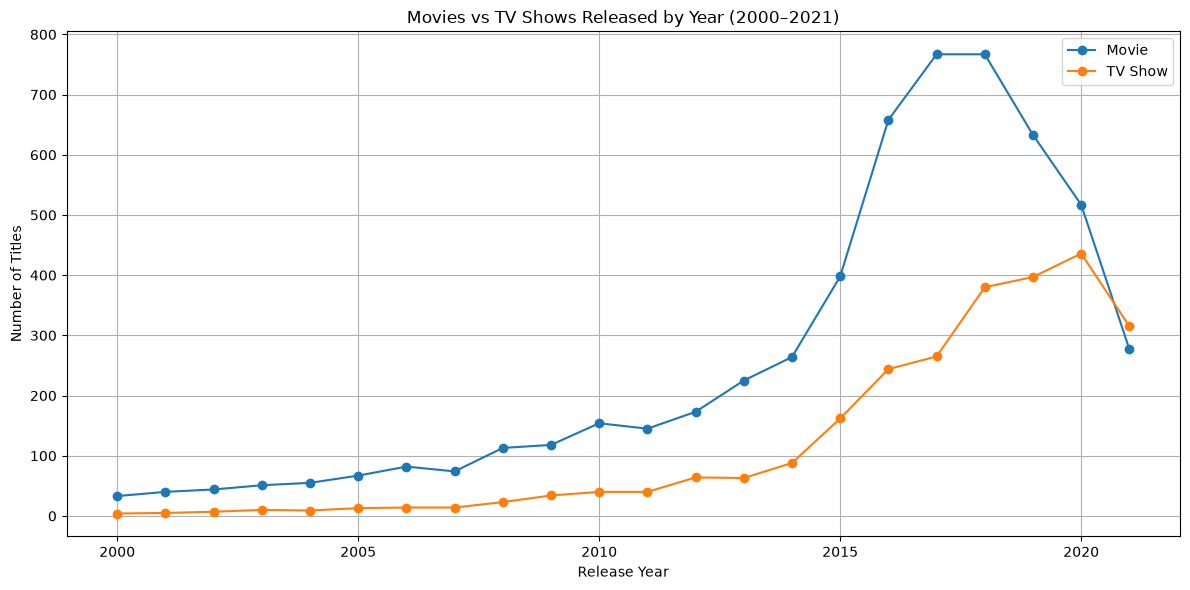

In [114]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_type_by_year.index,
    recent_type_by_year["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    recent_type_by_year.index,
    recent_type_by_year["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Movies vs TV Shows Released by Year (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [115]:
df_clean["country"].head(20)

0                                         United States
1                                          South Africa
2                                               Unknown
3                                               Unknown
4                                                 India
5                                               Unknown
6                                               Unknown
7     United States, Ghana, Burkina Faso, United Kin...
8                                        United Kingdom
9                                         United States
10                                              Unknown
11                                              Unknown
12                              Germany, Czech Republic
13                                              Unknown
14                                              Unknown
15                                        United States
16                                              Unknown
17                                              

### 3.4 Top Countries

The `country` column can contain multiple countries for a single title.
Therefore, the values are split and expanded so that each country can
be counted separately.

This analysis identifies the countries most frequently associated with
Netflix titles in the dataset.

In [116]:
country_data = df_clean["country"].str.split(", ").explode()

country_data.head(20)

0      United States
1       South Africa
2            Unknown
3            Unknown
4              India
5            Unknown
6            Unknown
7      United States
7              Ghana
7       Burkina Faso
7     United Kingdom
7            Germany
7           Ethiopia
8     United Kingdom
9      United States
10           Unknown
11           Unknown
12           Germany
12    Czech Republic
13           Unknown
Name: country, dtype: str

In [117]:
country_counts = country_data.value_counts()

country_counts.head(10)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [118]:
country_counts_clean = country_counts.drop("Unknown")

country_counts_clean.head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

#### Visualization

The bar chart below shows the top 10 countries associated with Netflix
titles.

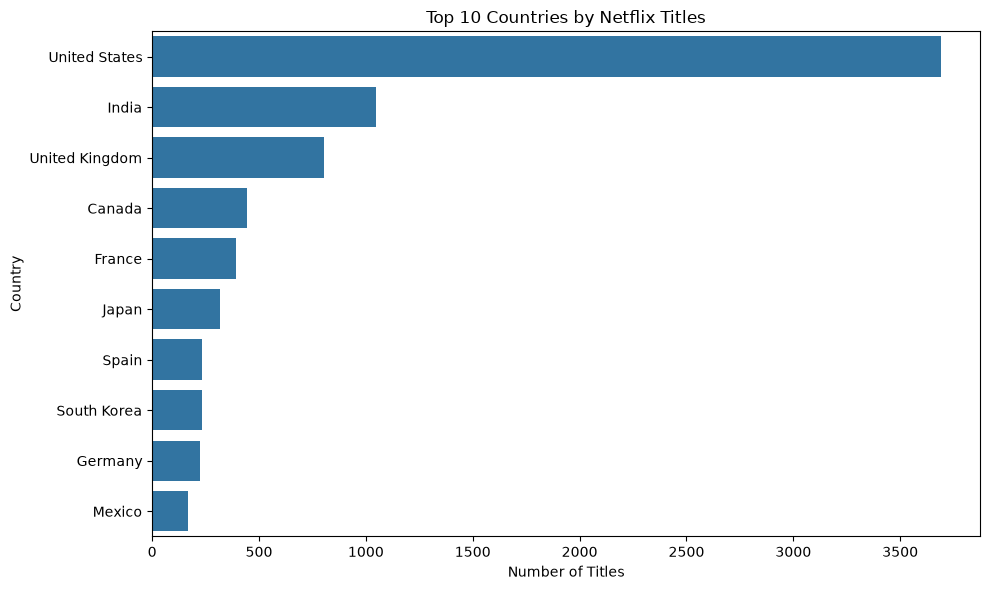

In [119]:
top_countries = country_counts_clean.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

#### Key Insight

The United States is the country most frequently associated with
Netflix titles in the dataset, followed by India and the United Kingdom.

This indicates that the Netflix catalog has strong representation from
these countries.

Note: A single title can be associated with multiple countries, so these
counts represent country associations rather than exclusive title
counts.

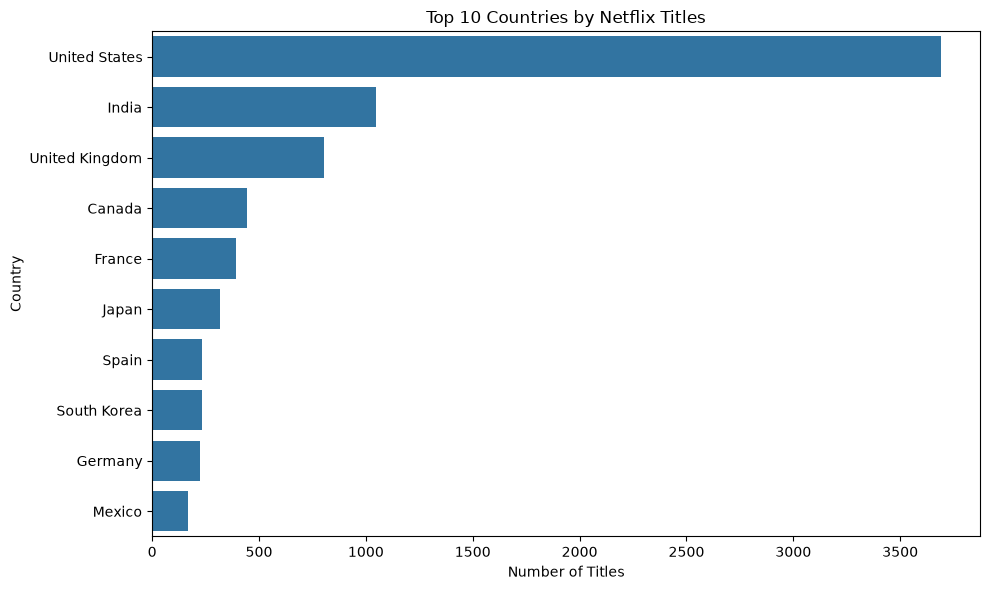

In [120]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_countries.png",
    dpi=300
)

plt.show()

In [121]:
df_clean["listed_in"].head(20)

0                                         Documentaries
1       International TV Shows, TV Dramas, TV Mysteries
2     Crime TV Shows, International TV Shows, TV Act...
3                                Docuseries, Reality TV
4     International TV Shows, Romantic TV Shows, TV ...
5                    TV Dramas, TV Horror, TV Mysteries
6                              Children & Family Movies
7      Dramas, Independent Movies, International Movies
8                          British TV Shows, Reality TV
9                                      Comedies, Dramas
10    Crime TV Shows, Docuseries, International TV S...
11    Crime TV Shows, International TV Shows, TV Act...
12                         Dramas, International Movies
13                   Children & Family Movies, Comedies
14         British TV Shows, Crime TV Shows, Docuseries
15                               TV Comedies, TV Dramas
16                  Documentaries, International Movies
17    Crime TV Shows, Spanish-Language TV Shows,

### 3.5 Top Categories

The `listed_in` column contains multiple categories for some titles.
The categories are split and expanded so that each category can be
counted separately.

This analysis helps identify the most common types of content in the
Netflix dataset.

In [122]:
genre_data = df_clean["listed_in"].str.split(", ").explode()

genre_data.head(20)

0               Documentaries
1      International TV Shows
1                   TV Dramas
1                TV Mysteries
2              Crime TV Shows
2      International TV Shows
2       TV Action & Adventure
3                  Docuseries
3                  Reality TV
4      International TV Shows
4           Romantic TV Shows
4                 TV Comedies
5                   TV Dramas
5                   TV Horror
5                TV Mysteries
6    Children & Family Movies
7                      Dramas
7          Independent Movies
7        International Movies
8            British TV Shows
Name: listed_in, dtype: str

In [123]:
genre_counts = genre_data.value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

#### Visualization

The bar chart below shows the 10 most frequently occurring categories
in the Netflix dataset.

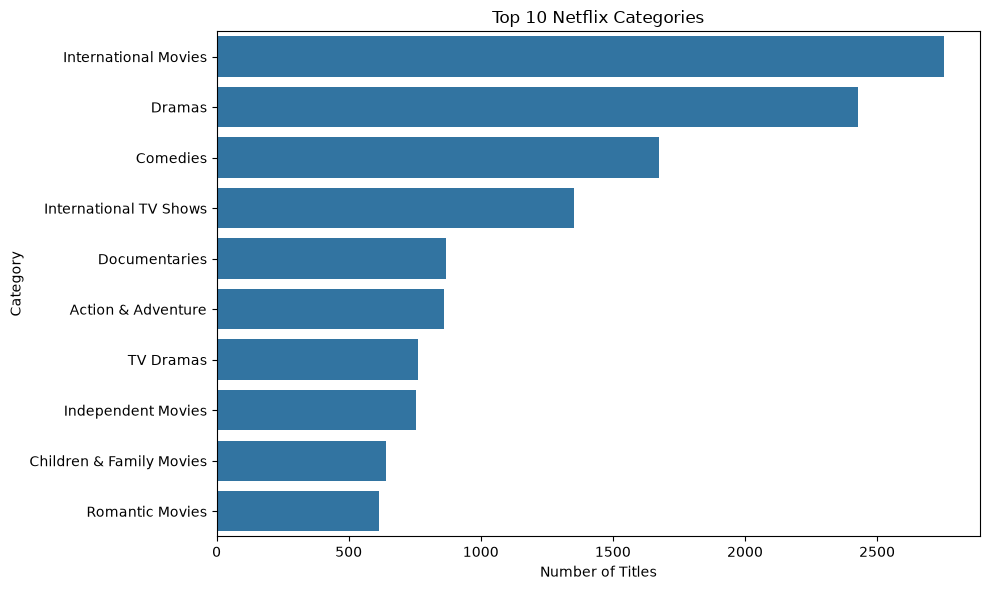

In [124]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

#### Key Insight

International Movies are the most frequently occurring category in the
dataset, followed by Dramas and Comedies.

This shows that Netflix has a strong presence of international content
as well as popular genres such as drama and comedy.

Note: A single title can belong to multiple categories, so the category
counts can overlap.

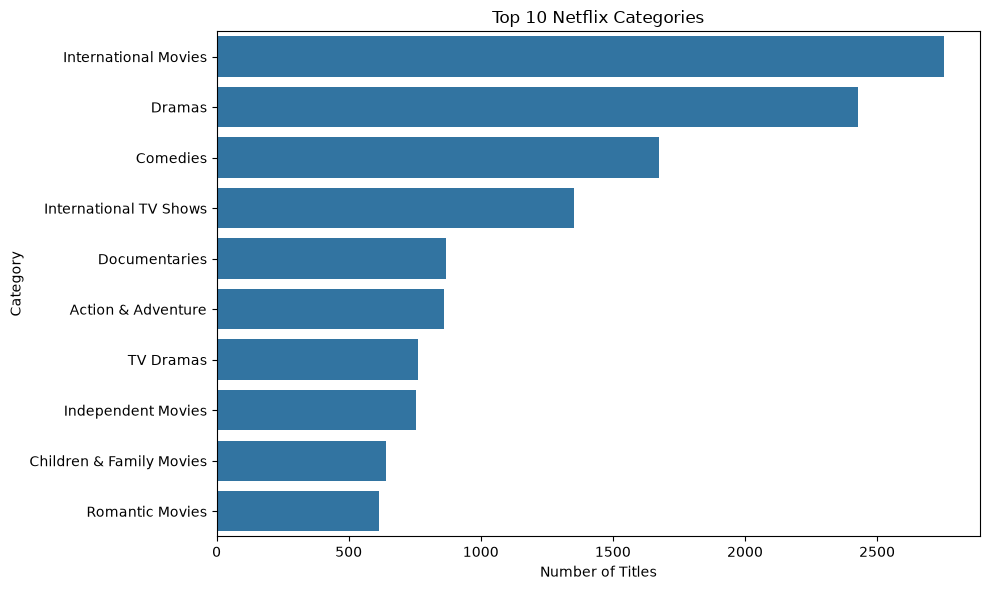

In [125]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_genres.png",
    dpi=300
)

plt.show()

### 3.6 Content Ratings

This analysis examines the content ratings assigned to Netflix titles.

Understanding the distribution of ratings helps identify the types of
audiences that the titles in the dataset are intended for.

In [126]:
rating_counts = df_clean["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [127]:
df_clean[
    df_clean["rating"].str.contains("min", na=False)
][["title", "type", "rating", "duration"]]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,Unknown
5794,Louis C.K.: Hilarious,Movie,84 min,Unknown
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,Unknown


### Correcting Incorrect Rating Values

During data inspection, three values in the `rating` column were found
to contain movie durations (`74 min`, `84 min`, and `66 min`) instead of
content ratings.

These values were moved to the `duration` column and replaced with
`Unknown` in the `rating` column.

This correction prevents incorrect values from affecting the rating
analysis.

In [128]:
invalid_ratings = df_clean["rating"].str.contains("min", na=False)

df_clean.loc[invalid_ratings, "duration"] = df_clean.loc[
    invalid_ratings, "rating"
]

df_clean.loc[invalid_ratings, "rating"] = "Unknown"

In [129]:
df_clean["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

#### Visualization

The bar chart below shows the 10 most common content ratings in the
Netflix dataset.

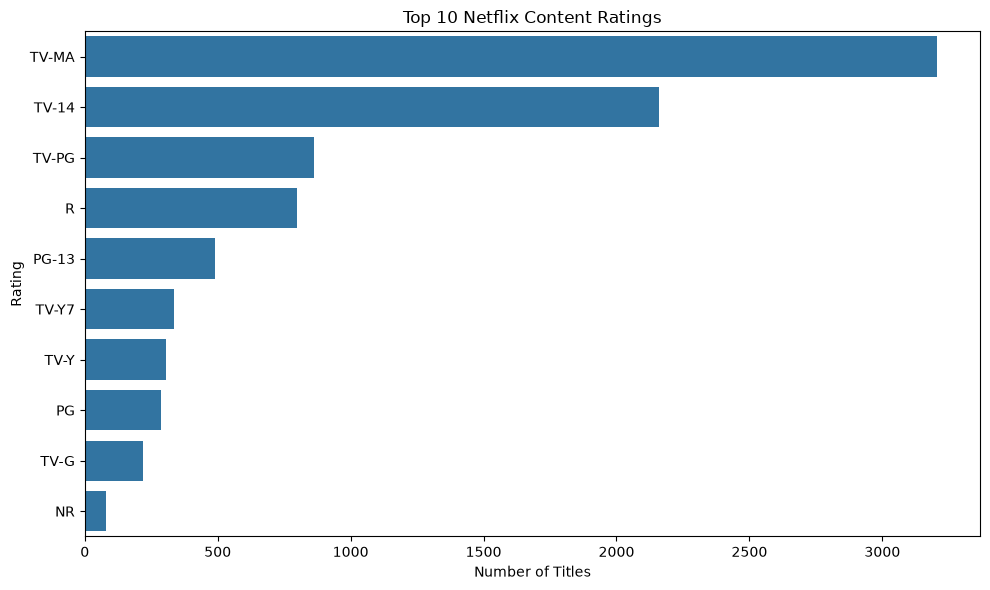

In [130]:
top_ratings = df_clean["rating"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

#### Key Insight

TV-MA is the most frequently occurring content rating in the dataset,
followed by TV-14 and TV-PG.

This shows that titles with these ratings make up a substantial portion
of the Netflix catalog represented in this dataset.

The analysis describes the rating distribution in the dataset and does
not represent the entire current Netflix catalog.

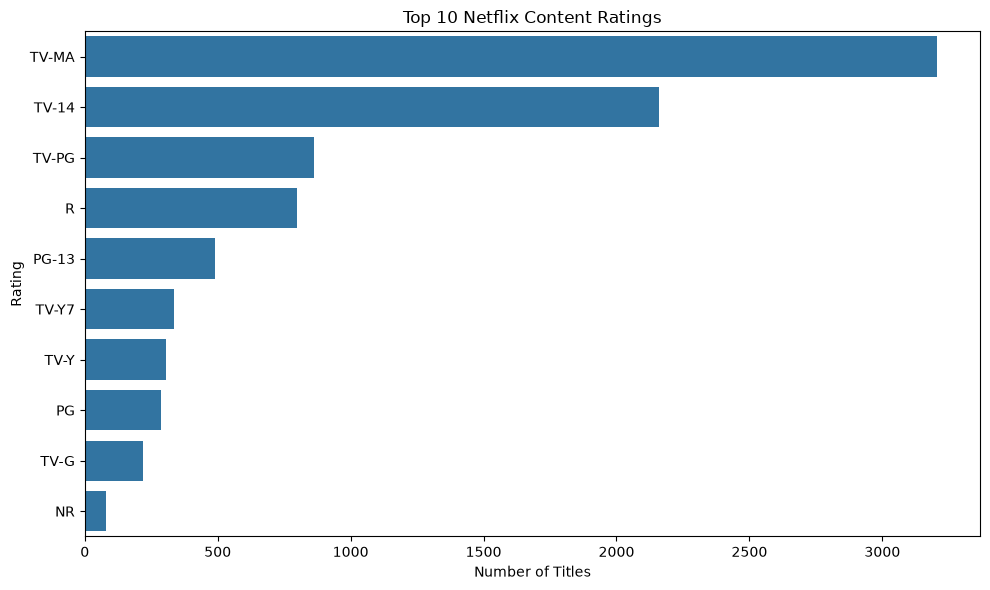

In [131]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_ratings.png",
    dpi=300
)

plt.show()

In [132]:
df_clean["duration"].head(20)

0        90 min
1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
6        91 min
7       125 min
8     9 Seasons
9       104 min
10     1 Season
11     1 Season
12      127 min
13       91 min
14     1 Season
15    4 Seasons
16       67 min
17    2 Seasons
18       94 min
19     1 Season
Name: duration, dtype: str

### 3.7 Movie Duration Analysis

This analysis examines the duration of movies in the Netflix dataset.

The duration values are extracted from the `duration` column and
converted into numerical values representing minutes.

The average and median movie durations are also calculated to
understand the typical length of a Netflix movie.

In [133]:
movie_duration = df_clean.loc[
    df_clean["type"] == "Movie",
    "duration"
]

movie_duration.head(20)

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
13     91 min
16     67 min
18     94 min
22    161 min
23     61 min
24    166 min
26    147 min
27    103 min
28     97 min
29    106 min
30    111 min
35    110 min
36    105 min
38     96 min
41    124 min
Name: duration, dtype: str

In [134]:
movie_minutes = movie_duration.str.extract(r"(\d+)")[0].astype(float)

movie_minutes.head(20)

0      90.0
6      91.0
7     125.0
9     104.0
12    127.0
13     91.0
16     67.0
18     94.0
22    161.0
23     61.0
24    166.0
26    147.0
27    103.0
28     97.0
29    106.0
30    111.0
35    110.0
36    105.0
38     96.0
41    124.0
Name: 0, dtype: float64

In [135]:
movie_minutes.describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: 0, dtype: float64

In [136]:
print("Average movie duration:", movie_minutes.mean())
print("Median movie duration:", movie_minutes.median())

Average movie duration: 99.56499755341706
Median movie duration: 98.0


#### Visualization

The histogram below shows the distribution of movie durations in
minutes.

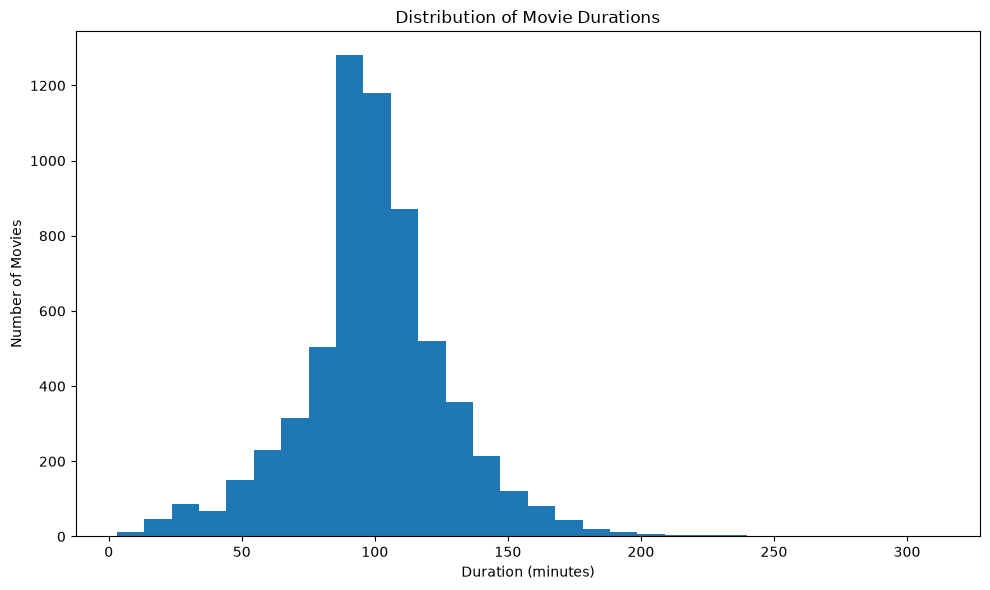

In [137]:
plt.figure(figsize=(10, 6))

plt.hist(movie_minutes, bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

#### Key Insight

The average movie duration is approximately 99.6 minutes, while the
median duration is 98 minutes.

This indicates that a typical movie in the dataset is around 100 minutes
long.

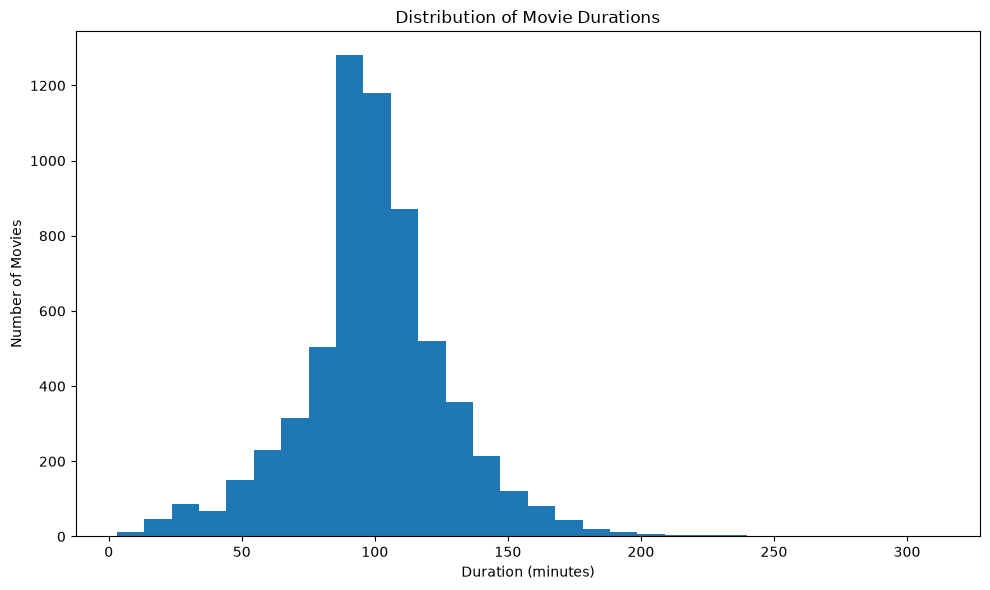

In [138]:
plt.figure(figsize=(10, 6))

plt.hist(movie_minutes, bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig(
    "../visualizations/movie_duration_distribution.png",
    dpi=300
)

plt.show()

### 3.8 TV Show Seasons Analysis

This analysis examines the number of seasons in Netflix TV Shows.

The season information is extracted from the `duration` column and
converted into numerical values.

The average and median number of seasons are calculated to understand
the typical length of a TV Show in the dataset.

In [139]:
tv_duration = df_clean.loc[
    df_clean["type"] == "TV Show",
    "duration"
]

tv_duration.head(20)

1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
8     9 Seasons
10     1 Season
11     1 Season
14     1 Season
15    4 Seasons
17    2 Seasons
19     1 Season
20     1 Season
21    5 Seasons
25    2 Seasons
31     1 Season
32    3 Seasons
33     1 Season
34     1 Season
37     1 Season
Name: duration, dtype: str

In [140]:
tv_seasons = tv_duration.str.extract(r"(\d+)")[0].astype(float)

tv_seasons.head(20)

1     2.0
2     1.0
3     1.0
4     2.0
5     1.0
8     9.0
10    1.0
11    1.0
14    1.0
15    4.0
17    2.0
19    1.0
20    1.0
21    5.0
25    2.0
31    1.0
32    3.0
33    1.0
34    1.0
37    1.0
Name: 0, dtype: float64

In [141]:
print("Average number of seasons:", tv_seasons.mean())
print("Median number of seasons:", tv_seasons.median())

Average number of seasons: 1.764947683109118
Median number of seasons: 1.0


In [142]:
season_counts = tv_seasons.value_counts().sort_index()

season_counts

0
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

#### Visualization

The bar chart below shows the distribution of TV Shows according to
their number of seasons.

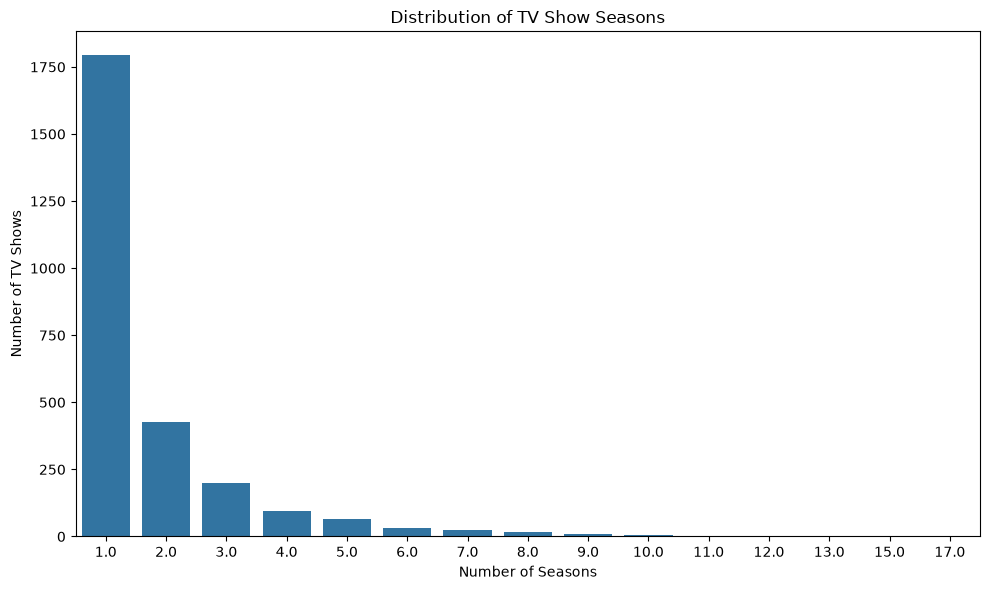

In [143]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.tight_layout()
plt.show()

#### Key Insight

Most TV Shows in the dataset have only one season.

The average number of seasons is approximately 1.76, while the median
is 1 season. This indicates that one-season TV Shows are much more
common than multi-season shows in this dataset.

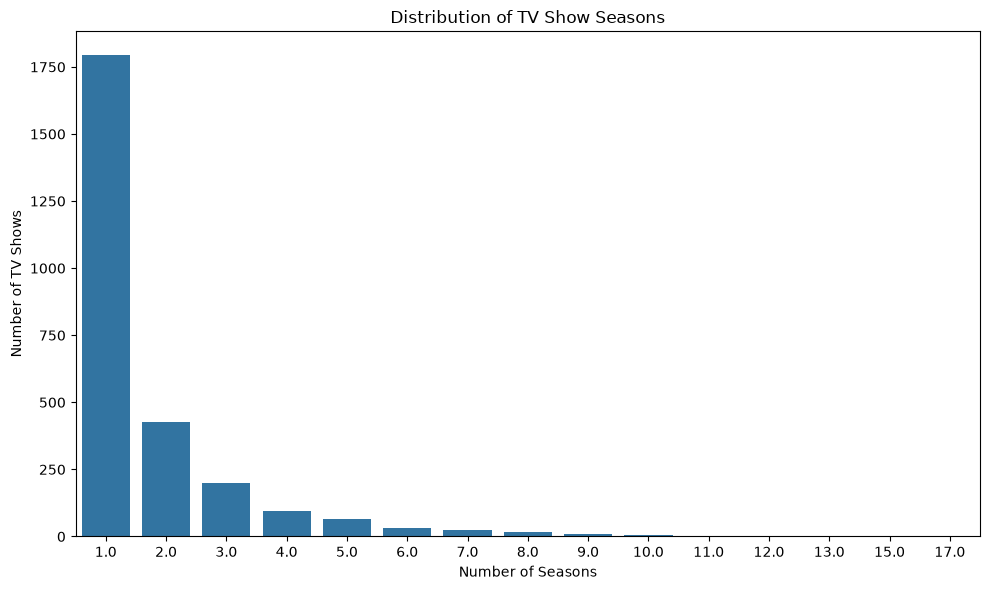

In [144]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.tight_layout()

plt.savefig(
    "../visualizations/tv_show_seasons.png",
    dpi=300
)

plt.show()

# Netflix Movies and TV Shows - Data Analysis

## Project Overview

This project analyzes the Netflix Movies and TV Shows dataset to understand
the type of content available on Netflix and identify important patterns
in its movies and TV shows.

The analysis focuses on content types, release years, countries,
categories, ratings, movie durations, and TV show seasons.

## Objectives

- Understand the structure of the Netflix dataset
- Clean and prepare the data for analysis
- Analyze the distribution of Movies and TV Shows
- Identify trends in content releases over time
- Find the countries with the most Netflix titles
- Identify the most common content categories
- Analyze content ratings
- Study movie durations and TV show seasons

## Dataset

The dataset contains information about Netflix movies and TV shows,
including their title, type, director, cast, country, release year,
rating, duration, categories, and description.

### Final Data Check

After cleaning the dataset, the cleaned DataFrame was checked to ensure
that the important missing values and incorrect entries had been handled
appropriately.

The cleaned dataset is now ready for exploratory data analysis.

In [145]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

## 4. Key Findings

The exploratory data analysis produced several important findings:

- Movies account for approximately 69.6% of the titles, while TV Shows
  account for approximately 30.4%.
- The number of Netflix titles in the dataset increases substantially
  in the more recent release years.
- Movies consistently outnumber TV Shows across most of the years
  analyzed.
- The United States is the country most frequently associated with
  Netflix titles, followed by India and the United Kingdom.
- International Movies, Dramas, and Comedies are among the most common
  categories.
- TV-MA is the most frequently occurring content rating in the dataset.
- The average movie duration is approximately 99.6 minutes, with a
  median of 98 minutes.
- Most TV Shows have only one season, with a median of 1 season.

## 5. Conclusion

This project explored the Netflix Movies and TV Shows dataset through
data cleaning and exploratory data analysis.

The analysis revealed patterns in content types, release years,
countries, categories, ratings, movie durations, and TV show seasons.

The project demonstrates how Python, Pandas, Matplotlib, and Seaborn
can be used to clean real-world data, explore patterns, and communicate
findings through visualizations.